# Landsat image-regression inputs

This notebook verifies the framework-neutral, lazy inputs used to predict clear Landsat land-surface temperature from the surrounding 100 m of Soil sealing, high green, and Urban Atlas water. It uses the latest prepared observation and performs no model fitting or network downloads.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'processing/local-layers').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'processing/local-layers/src'))

from greenwave_local_layers.image_regression import (
    CHANNEL_NAMES, DEFAULT_OBSERVATION_ID, ImageRegressionDataset,
    SUPPORT_MASK, load_regression_catalog, make_sector_folds,
    prepare_regression_catalog,
)

try:
    catalog = load_regression_catalog(DEFAULT_OBSERVATION_ID)
except FileNotFoundError:
    catalog = prepare_regression_catalog(DEFAULT_OBSERVATION_ID)
samples = catalog.samples
spatial_dataset = ImageRegressionDataset(catalog, representation='spatial')
radial_dataset = ImageRegressionDataset(catalog, representation='radial')

In [2]:
manifest = catalog.manifest
summary = pd.Series({
    'Observation': catalog.observation_id,
    'Samples': f'{len(samples):,}',
    'Covered Statbel sectors': samples['sector_id'].nunique(),
    'LST range (°C)': f"{samples['lst_c'].min():.2f} – {samples['lst_c'].max():.2f}",
    'Soil-sealing year': manifest['channels'][0]['year'],
    'High-green year': manifest['channels'][1]['year'],
    'Urban Atlas year': manifest['channels'][2]['year'],
    'Eligibility': 'clear LST; centre in sealed soil and UA urban fabric; complete 100 m disk',
})
display(summary.to_frame('Value'))

,Value
Observation,landsat-2026-06-22
Samples,"15,389"
Covered Statbel sectors,146
LST range (°C),21.62 – 43.91
Soil-sealing year,2024
High-green year,2021
Urban Atlas year,2021
Eligibility,clear LST; centre in sealed soil and UA urban ...


## Leakage-controlled spatial folds

Whole Statbel sectors are assigned to one fold. Training centres within 200 m of the held-out sector union are excluded, preventing two 100 m input disks from overlapping. Any future input or target normalisation must be fitted on `train_indices` only.

In [3]:
folds = make_sector_folds(samples, n_splits=5, buffer_m=200, seed=42)
diagnostics = pd.DataFrame([{'fold': fold.fold, **fold.diagnostics} for fold in folds])
display(diagnostics)

for fold in folds:
    train = samples.iloc[fold.train_indices]
    test = samples.iloc[fold.test_indices]
    assert set(train['sector_id']).isdisjoint(test['sector_id'])
    assert set(train['site_id']).isdisjoint(test['site_id'])
print('Verified: all five folds are sector- and site-disjoint and satisfy the 200 m embargo.')

,fold,trainSampleCount,testSampleCount,excludedBufferSampleCount,trainSectorCount,testSectorCount,trainMunicipalities,testMunicipalities,bufferMeters
0,0,9602,3078,2709,115,28,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...",200.0
1,1,10274,3078,2037,112,28,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...",200.0
2,2,9254,3078,3057,109,30,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...",200.0
3,3,9245,3077,3067,114,30,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Drogenbos, Halle, Pepingen, Sint-Gen...",200.0
4,4,9283,3078,3028,108,30,"[Beersel, Drogenbos, Halle, Linkebeek, Pepinge...","[Beersel, Halle, Linkebeek, Pepingen, Sint-Gen...",200.0


Verified: all five folds are sector- and site-disjoint and satisfy the 200 m embargo.


## Six reproducible examples

The upper row preserves north-up spatial arrangement. The lower-left chart is the numerical annular profile; the remaining panels are the axis-free line images supplied to the second pipeline.

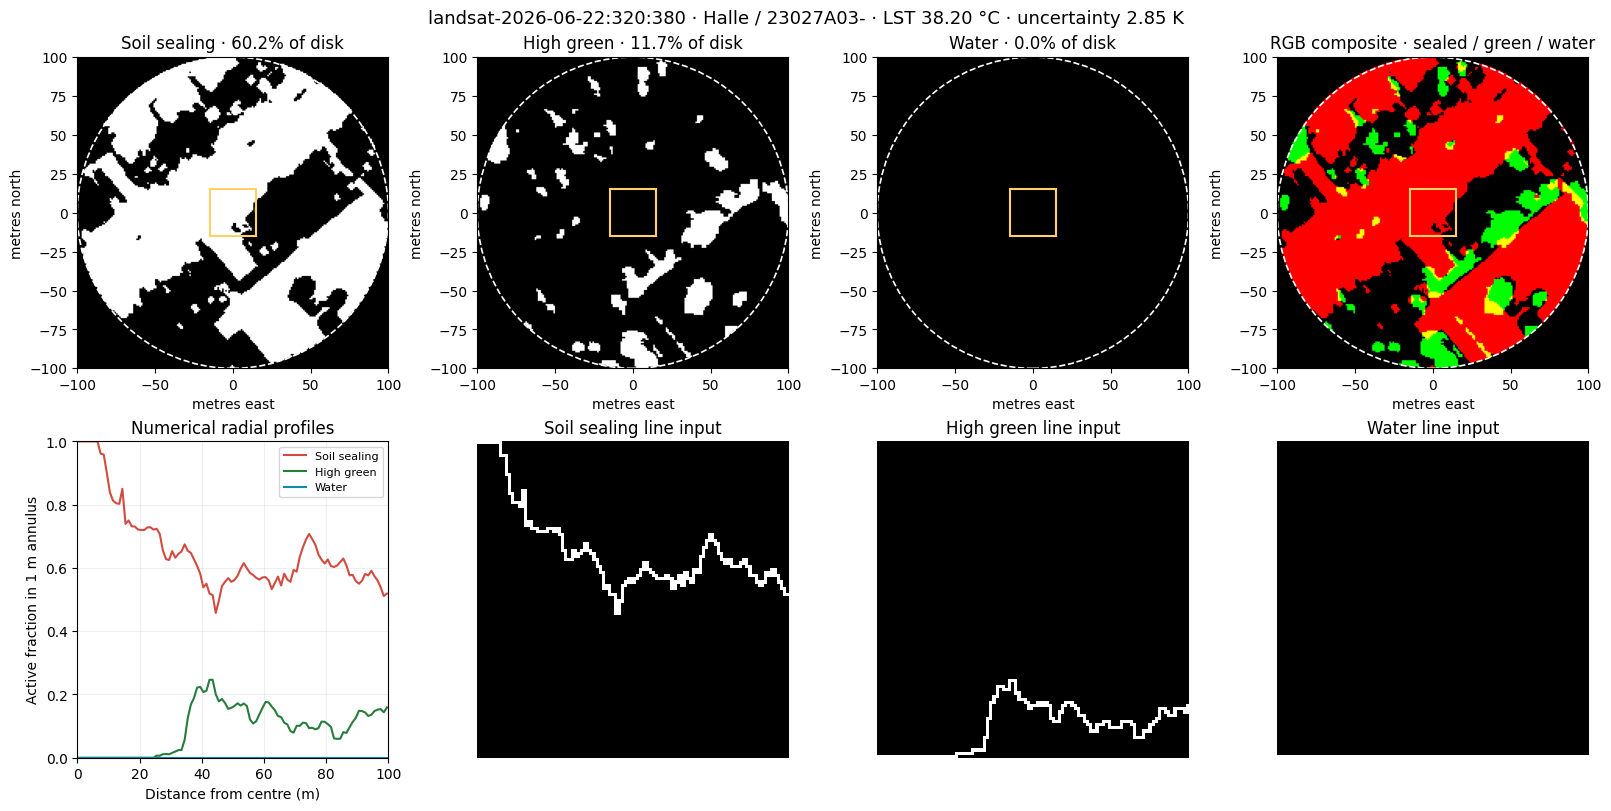

,Value
site_id,320:380
Lambert coordinates,"140504.52, 158945.03"
snap offset (m),0.483
ground coverage,100%
Soil sealing coverage,60.2%
High green coverage,11.7%
Water coverage,0.0%


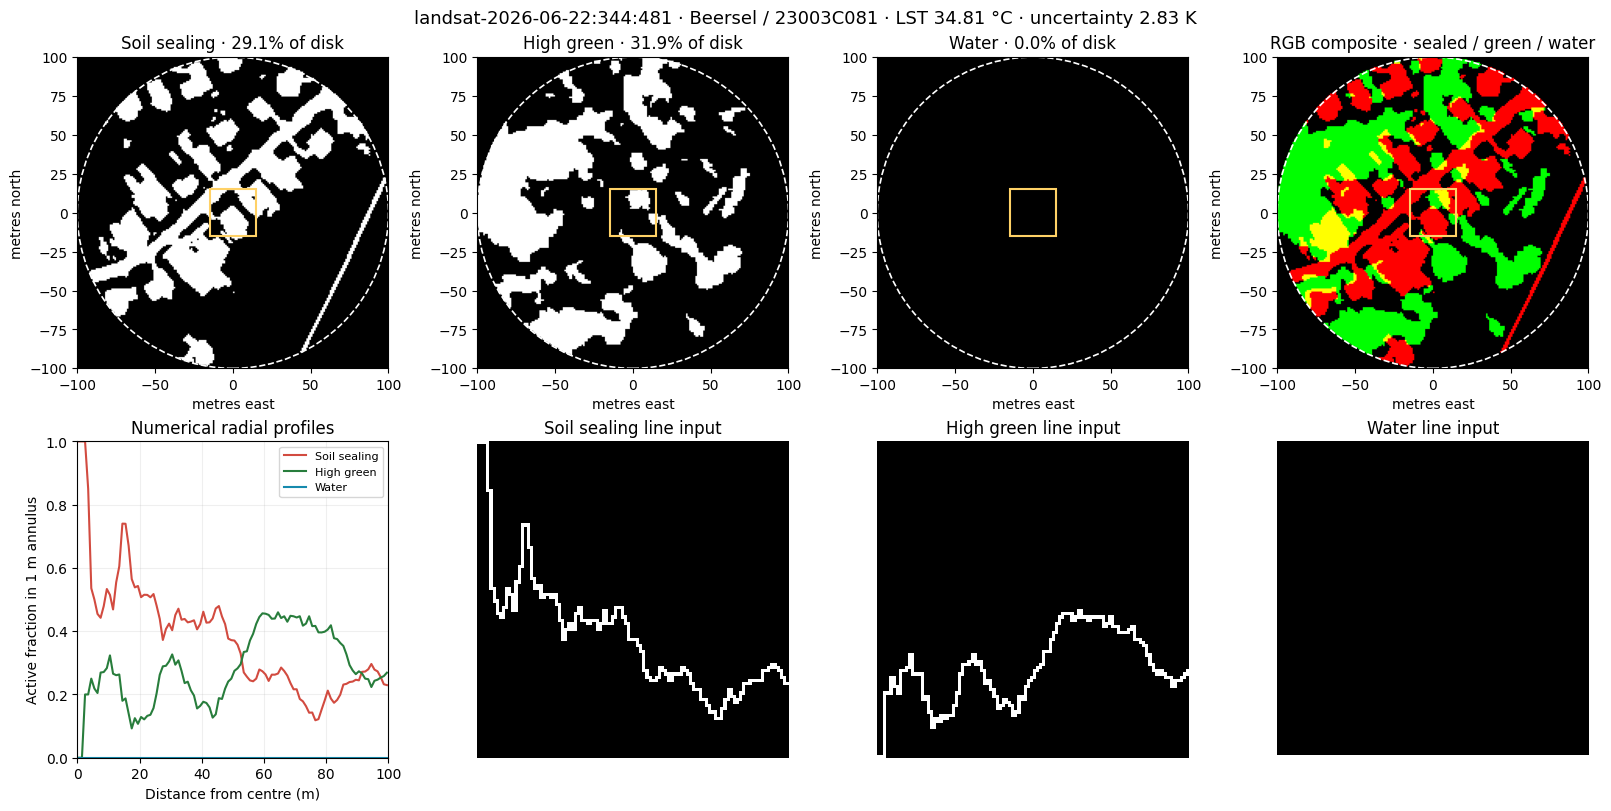

,Value
site_id,344:481
Lambert coordinates,"143521.46, 158168.96"
snap offset (m),0.457
ground coverage,100%
Soil sealing coverage,29.1%
High green coverage,31.9%
Water coverage,0.0%


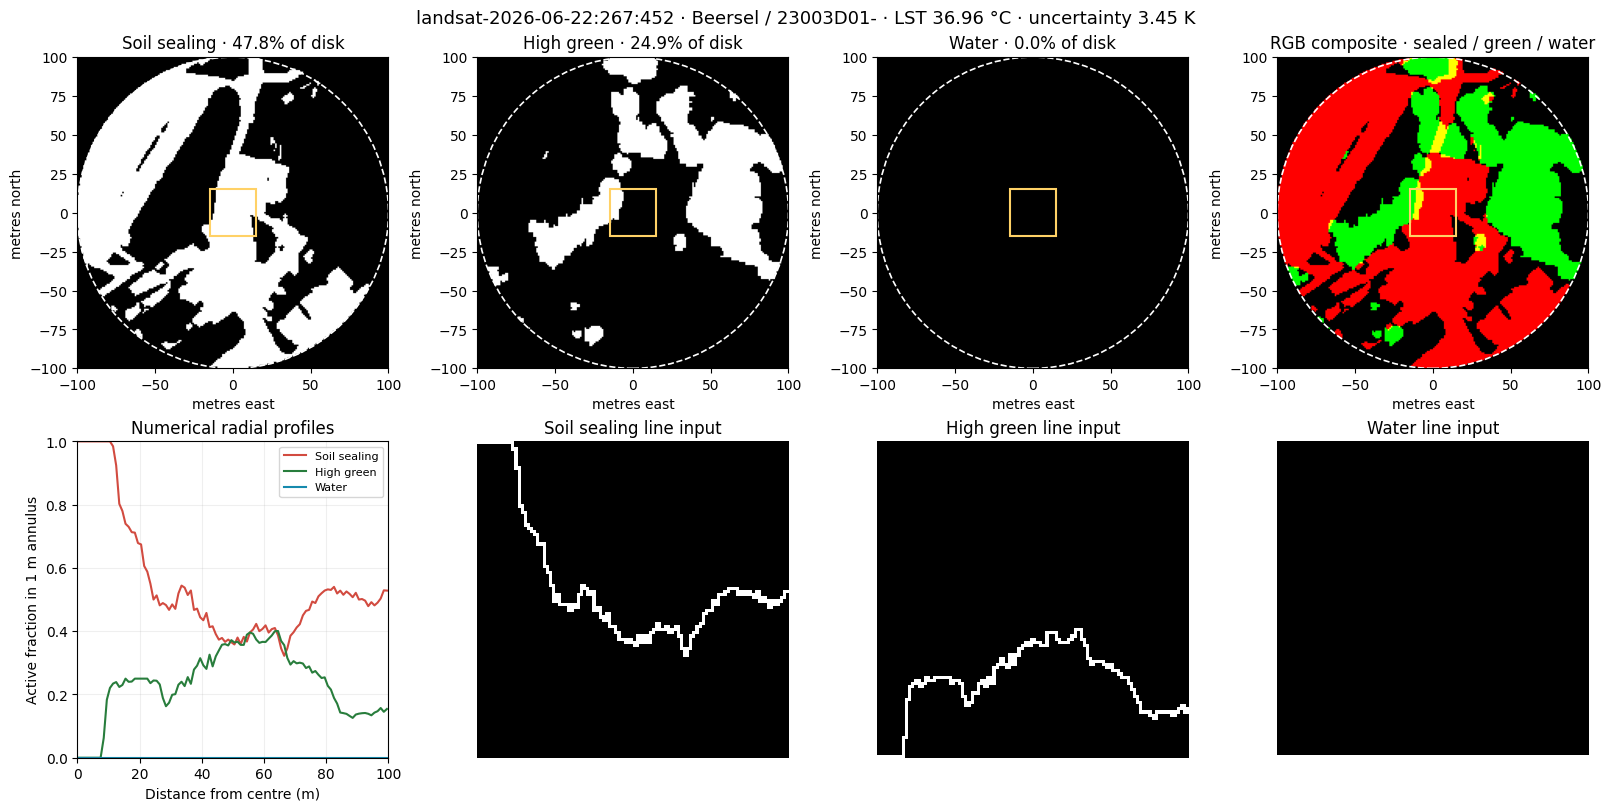

,Value
site_id,267:452
Lambert coordinates,"142694.10, 160495.23"
snap offset (m),0.249
ground coverage,100%
Soil sealing coverage,47.8%
High green coverage,24.9%
Water coverage,0.0%


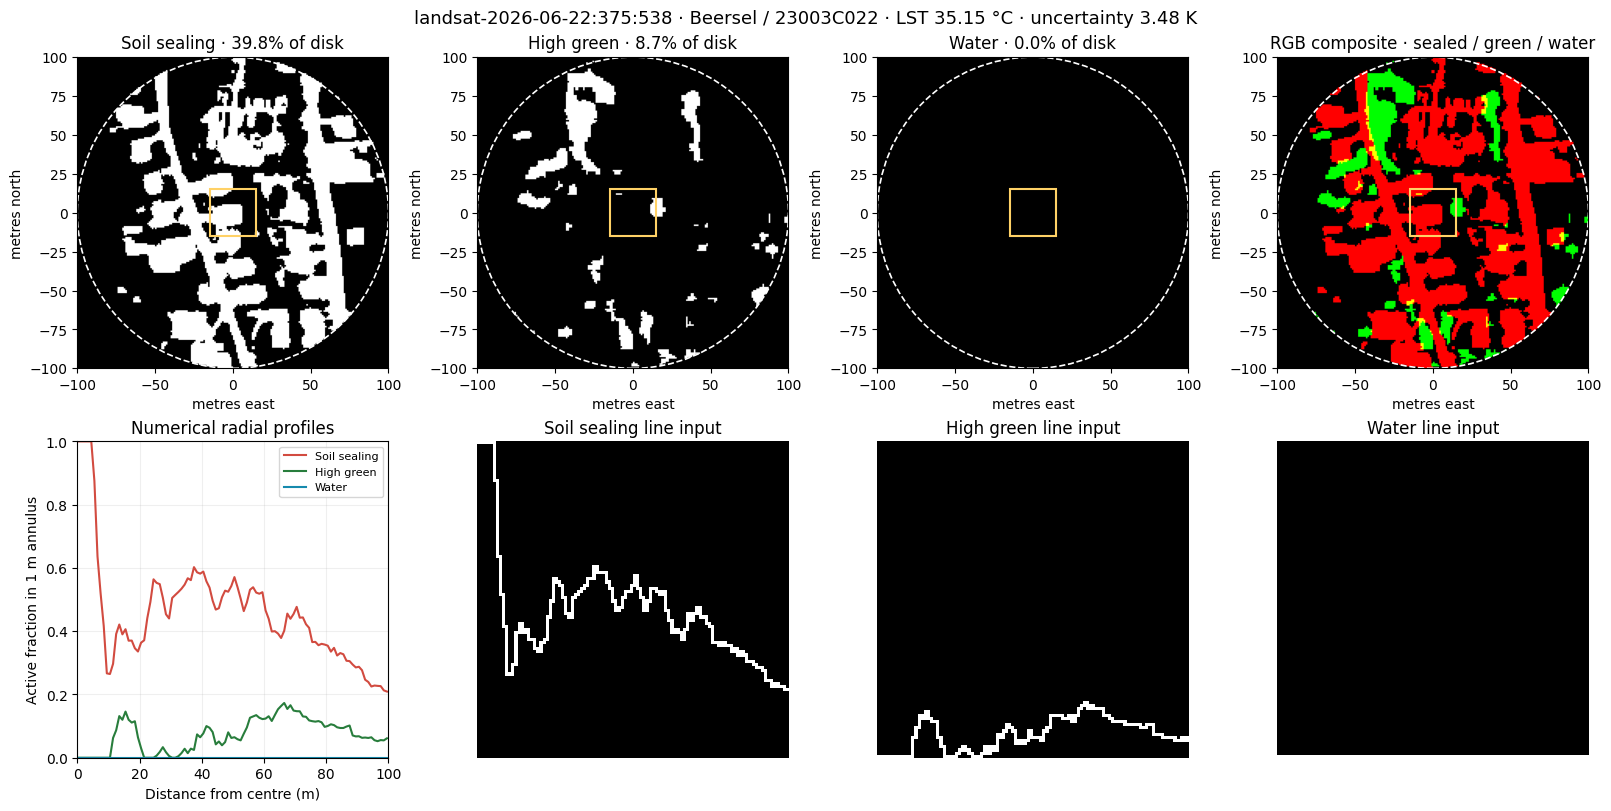

,Value
site_id,375:538
Lambert coordinates,"145214.39, 157207.28"
snap offset (m),0.482
ground coverage,100%
Soil sealing coverage,39.8%
High green coverage,8.7%
Water coverage,0.0%


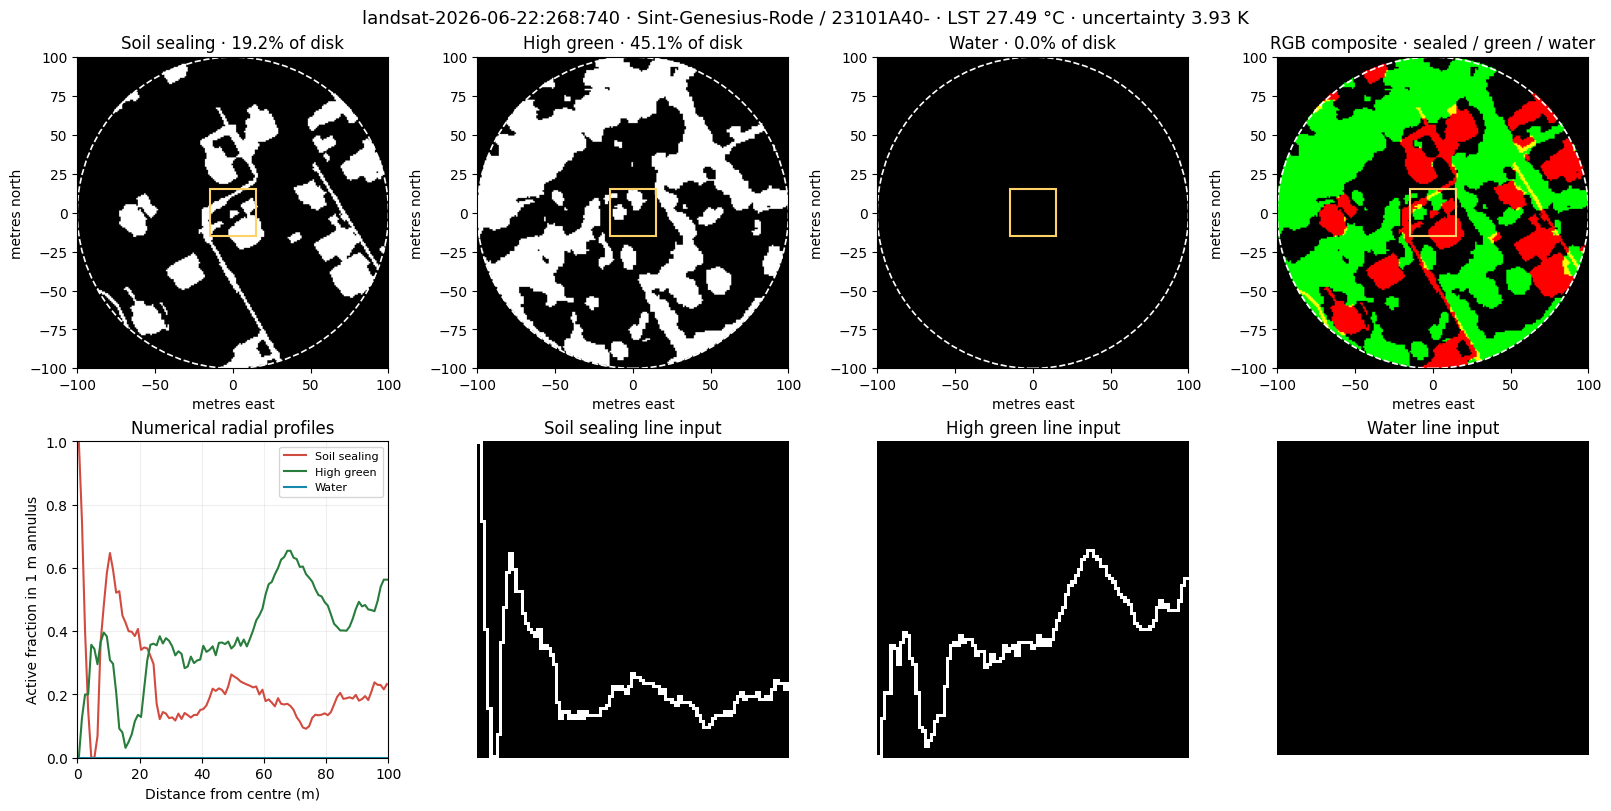

,Value
site_id,268:740
Lambert coordinates,"151334.16, 160305.44"
snap offset (m),0.467
ground coverage,100%
Soil sealing coverage,19.2%
High green coverage,45.1%
Water coverage,0.0%


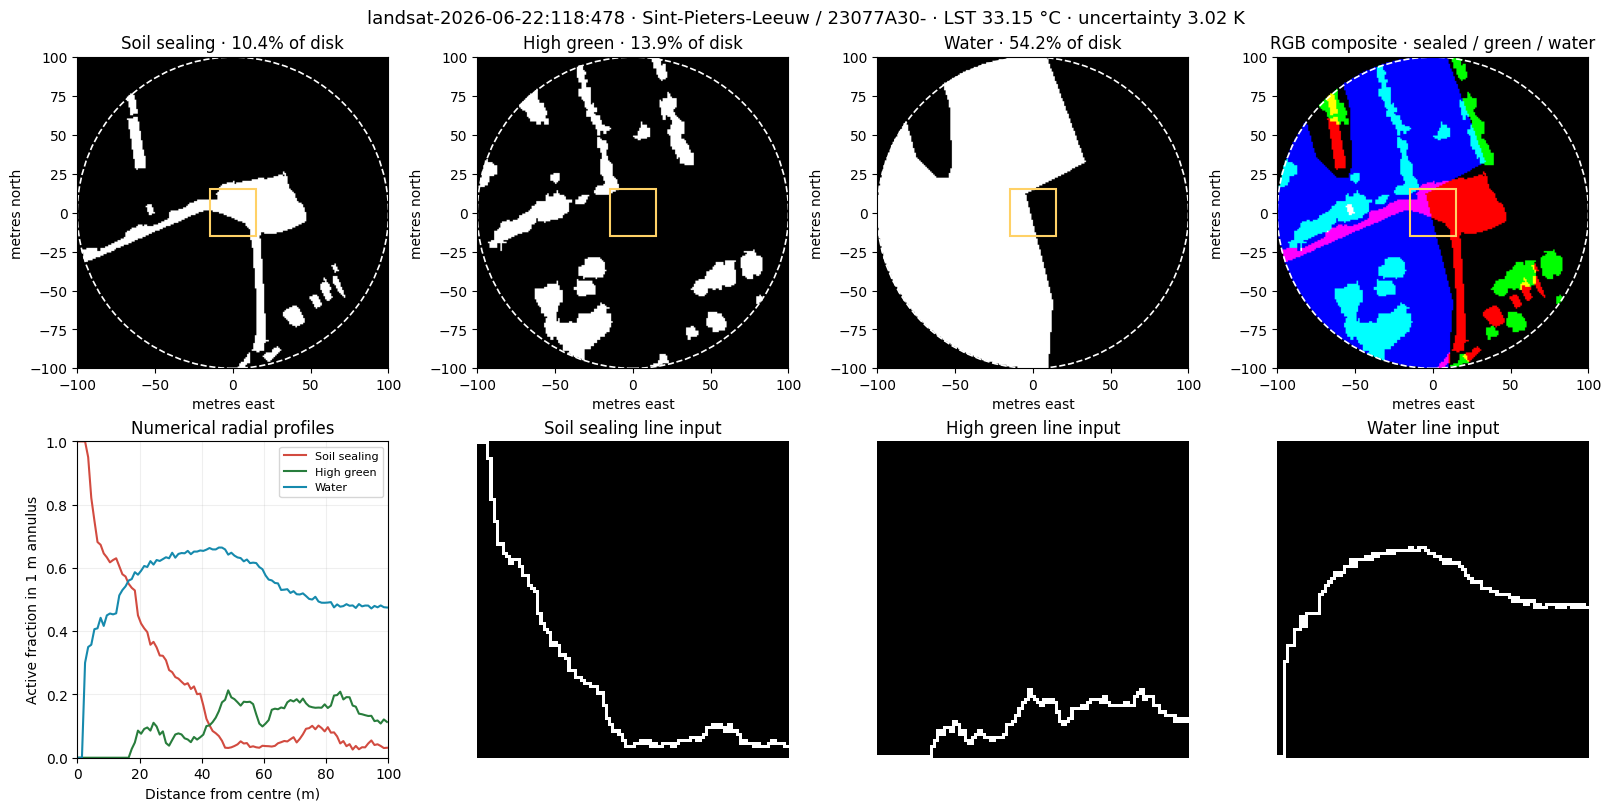

,Value
site_id,118:478
Lambert coordinates,"143556.84, 164951.17"
snap offset (m),0.234
ground coverage,100%
Soil sealing coverage,10.4%
High green coverage,13.9%
Water coverage,54.2%


In [4]:
RANDOM_SEED = 42
selected_indices = np.random.default_rng(RANDOM_SEED).choice(len(samples), size=6, replace=False)
channel_titles = ('Soil sealing', 'High green', 'Water')
channel_colors = ('#d24b40', '#287d3c', '#168aad')

def add_ground_overlays(axis):
    axis.add_patch(Circle((0, 0), 100, fill=False, color='white', linewidth=1.2, linestyle='--'))
    axis.add_patch(Rectangle((-15, -15), 30, 30, fill=False, color='#ffd166', linewidth=1.5))
    axis.set_xlim(-100, 100)
    axis.set_ylim(-100, 100)
    axis.set_aspect('equal')
    axis.set_xlabel('metres east')
    axis.set_ylabel('metres north')

for dataset_index in selected_indices:
    dataset_index = int(dataset_index)
    sample = spatial_dataset[dataset_index]
    patch = sample['input']
    profiles = spatial_dataset.profiles(dataset_index)
    radial = radial_dataset[dataset_index]['input']
    metadata = sample['metadata']
    coverage = patch[:, SUPPORT_MASK].mean(axis=1) * 100

    figure, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
    extent = (-100, 100, -100, 100)
    for channel, axis in enumerate(axes[0, :3]):
        axis.imshow(patch[channel], origin='upper', extent=extent, cmap='gray', vmin=0, vmax=1)
        add_ground_overlays(axis)
        axis.set_title(f'{channel_titles[channel]} · {coverage[channel]:.1f}% of disk')
    rgb = np.moveaxis(patch[[0, 1, 2]], 0, -1)
    axes[0, 3].imshow(rgb, origin='upper', extent=extent)
    add_ground_overlays(axes[0, 3])
    axes[0, 3].set_title('RGB composite · sealed / green / water')

    distances = np.arange(100) + 0.5
    for channel, color in enumerate(channel_colors):
        axes[1, 0].plot(distances, profiles[channel], color=color, label=channel_titles[channel])
    axes[1, 0].set(xlim=(0, 100), ylim=(0, 1), xlabel='Distance from centre (m)',
                   ylabel='Active fraction in 1 m annulus', title='Numerical radial profiles')
    axes[1, 0].grid(alpha=.2)
    axes[1, 0].legend(fontsize=8)
    for channel, axis in enumerate(axes[1, 1:]):
        axis.imshow(radial[channel], cmap='gray', vmin=0, vmax=1, aspect='auto')
        axis.set_title(f'{channel_titles[channel]} line input')
        axis.set_axis_off()

    figure.suptitle(
        f"{sample['sample_id']} · {metadata['municipality']} / {metadata['sector_id']} · "
        f"LST {float(sample['target']):.2f} °C · uncertainty {metadata['uncertainty_k']:.2f} K",
        fontsize=13,
    )
    plt.show()
    display(pd.Series({
        'site_id': sample['site_id'],
        'Lambert coordinates': f"{metadata['x_lambert']:.2f}, {metadata['y_lambert']:.2f}",
        'snap offset (m)': f"{metadata['snap_offset_m']:.3f}",
        'ground coverage': f"{metadata['ground_coverage']:.0%}",
        **{f'{name} coverage': f'{value:.1f}%' for name, value in zip(channel_titles, coverage)},
    }).to_frame('Value'))

In [5]:
spatial_dataset.close()
radial_dataset.close()
print('Notebook verification complete: no model was fitted.')

Notebook verification complete: no model was fitted.
